# Angular Distribution Plotting Demo

This notebook demonstrates the plotting capabilities for angular distributions from ACE files using the kika library.

**Features demonstrated:**
1. Loading and exploring angular distribution data
2. Basic plotting with PlotBuilder and to_plot_data()
3. Interpolated plotting for smoother curves
4. Comparing distributions at multiple energies
5. Differential cross-section plots (normalized to cross-section)
6. DataFrame access for custom analysis

In [1]:
import kika
from kika.plotting import PlotBuilder, PlotData
import matplotlib.pyplot as plt
import numpy as np

# Load ACE file for Fe-56
ace_file = r'c:\Users\Usuario\BaradDur\Dev\kika\files\ace\260560_80.02c'
ace = kika.read_ace(ace_file)
print(ace)

                                   ACE Format Data                                   
                                   Material: 2631                                    
                        ZA: 26056, Temperature: 2.5301e-08 K                         

ACE Data Components:
-------------------------------------------------------------------------------------
Component                                Access Information                        
-------------------------------------------------------------------------------------
Header Information                       Available: ace.header                     
Energy Grid & Cross Sections             Available: ace.esz_block                  
Nubar (ν) Data                           Available: ace.nubar                      
Delayed Neutron Data                     Not available                             
Reaction MT Numbers                      Available: ace.reaction_mt_data           
Reaction Q-values                        Ava

## 1. Explore Angular Distributions

In [2]:
# Display angular distribution container information
print(ace.angular_distributions)

                              Angular Distribution Container                              

This container holds angular distributions read directly from the ACE file.
Each distribution preserves the original data structure as found in the ACE format.

Angular distributions describe the probability of scattering as a function of the
cosine of the scattering angle (μ), which ranges from -1 (backward scattering) to
+1 (forward scattering).

Available Angular Distribution Data:
------------------------------------------------------------------------------------------
Distribution Type                        Status                                         
------------------------------------------------------------------------------------------
Elastic Scattering (MT=2)                Available (TABULATED)                          
Neutron Reactions                        Available (4 reactions)                        
  KALBACH_MANN                           3 reactions                   

In [3]:
# Check available MT numbers for neutron reactions
print("Available neutron MT numbers:", ace.angular_distributions.get_neutron_reaction_mt_numbers())

# Check elastic scattering distribution
if ace.angular_distributions.elastic:
    print("\nElastic scattering distribution:")
    print(ace.angular_distributions.elastic)

Available neutron MT numbers: [5, 16, 51, 91]

Elastic scattering distribution:
                       Tabulated Angular Distribution for MT=2                       

This object contains tabulated angular distribution data for reaction MT=2.

DISTRIBUTION STRUCTURE:
The tabulated format stores the angular distribution as explicit probability
density functions (PDFs) and cumulative distribution functions (CDFs) for a set of
incident energy points. The data is organized as follows:

1. Energy Grid: A set of incident neutron energies (E₁, E₂, ..., Eₙ)
2. For each energy point, the distribution includes:
   a. Interpolation flag (0=histogram, 1=linear-linear per ACE Table 20)
   b. Set of cosine values (μ) ranging from -1 to 1
   c. PDF values (probability density function) for each cosine
   d. CDF values (cumulative distribution function) for each cosine

INTERPOLATION METHODS:
- Between incident energy points: Linear interpolation of PDF values
- Within a cosine grid (μ values):
  * Hi

## 2. Basic Plotting with PlotBuilder

The recommended way to create angular distribution plots is using the `to_plot_data()` method combined with `PlotBuilder`. This provides a consistent interface across the library.

In [ ]:
# Use to_plot_data() with PlotBuilder for consistent plotting
ang_data = ace.angular_distributions.to_plot_data(
    mt=2, 
    energy=1.0,
    ace=ace,
    label='Fe-56 Elastic at 1 MeV'
)

fig = (PlotBuilder(style='light', figsize=(8, 6))
       .add_data(ang_data)
       .set_labels(
           title='Fe-56 Elastic Scattering at 1 MeV',
           x_label=r'Scattering Angle Cosine ($\mu$)',
           y_label='Probability Density'
       )
       .set_grid(grid=True, alpha=0.3)
       .build())
plt.show()

## 3. Interpolated Plotting for Smoother Curves

By default, `to_plot_data()` returns the original data points. Use `interpolate=True` and `num_points` for smoother visualization.

In [ ]:
# Use interpolate=True for smoother curves
ang_data = ace.angular_distributions.to_plot_data(
    mt=2, 
    energy=1.0,
    ace=ace,
    label='E = 1.0 MeV',
    interpolate=True,
    num_points=200
)

fig = (PlotBuilder(style='light', figsize=(8, 6))
       .add_data(ang_data)
       .set_labels(
           title='Fe-56 Elastic Angular Distribution (Interpolated)',
           x_label=r'Scattering Angle Cosine ($\mu$)',
           y_label='Probability Density'
       )
       .set_grid(grid=True, alpha=0.3)
       .build())
plt.show()

## 4. Compare Multiple Energies

Use PlotBuilder's `add_data()` method to combine multiple angular distributions at different energies.

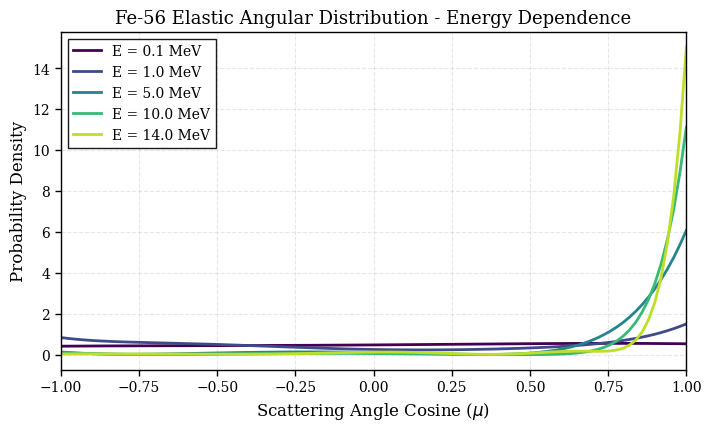

In [6]:
# Compare angular distributions at different energies
energies = [0.1, 1.0, 5.0, 10.0, 14.0]  # MeV
colors = plt.cm.viridis(np.linspace(0, 0.9, len(energies)))

builder = PlotBuilder(style='light', figsize=(10, 6))

for i, E in enumerate(energies):
    ang_data = ace.angular_distributions.to_plot_data(
        mt=2, 
        energy=E,
        ace=ace,
        label=f'E = {E} MeV',
        interpolate=True,
        color=colors[i]
    )
    builder.add_data(ang_data)

fig = (builder
       .set_labels(
           title='Fe-56 Elastic Angular Distribution - Energy Dependence',
           x_label=r'Scattering Angle Cosine ($\mu$)',
           y_label='Probability Density'
       )
       .set_legend(loc='upper left')
       .build())
plt.show()

## 5. Differential Cross-Section (Normalized to XS)

The angular distribution PDF is normalized such that it integrates to 1. For physics applications, you often need the differential cross-section:

$$\frac{d\sigma}{d\mu} = \sigma(E) \cdot P(\mu, E)$$

Use `normalize_to_xs=True` to get this directly.

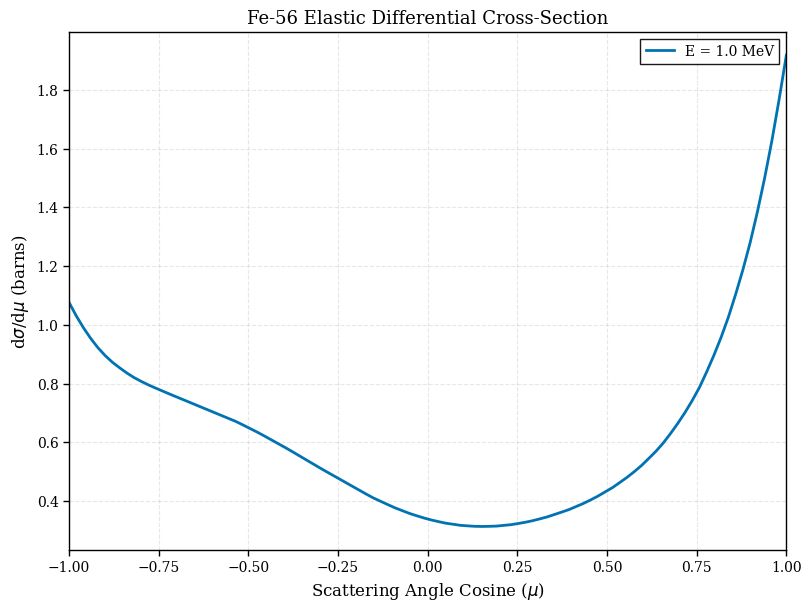

In [7]:
# Plot differential cross-section dsigma/dmu instead of PDF
ang_data_xs = ace.angular_distributions.to_plot_data(
    mt=2, 
    energy=1.0,
    ace=ace,
    label='E = 1.0 MeV',
    interpolate=True,
    normalize_to_xs=True  # NEW FEATURE
)

fig = (PlotBuilder(style='light', figsize=(8, 6))
       .add_data(ang_data_xs)
       .set_labels(
           title='Fe-56 Elastic Differential Cross-Section',
           x_label=r'Scattering Angle Cosine ($\mu$)',
           y_label=r'd$\sigma$/d$\mu$ (barns)'
       )
       .build())
plt.show()

## 6. Side-by-Side: PDF vs Differential Cross-Section

C:\Users\Usuario\AppData\Local\Temp\ipykernel_33096\179651727.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


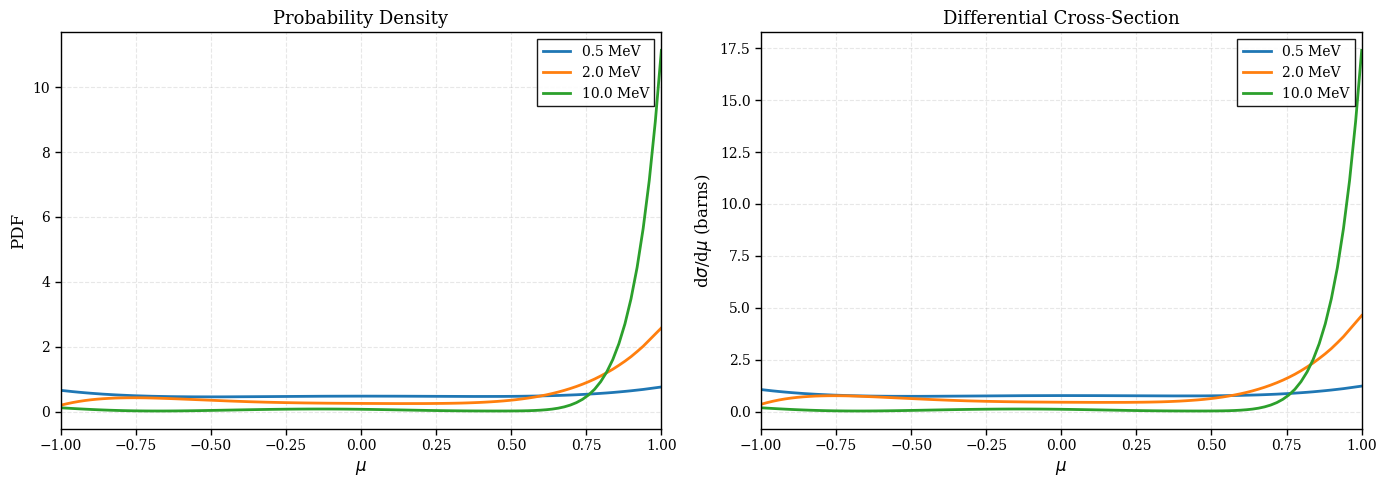

In [8]:
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

energy_list = [0.5, 2.0, 10.0]
colors = ['C0', 'C1', 'C2']

# Left: PDF
builder1 = PlotBuilder(ax=ax1, style='light')
for E, c in zip(energy_list, colors):
    data = ace.angular_distributions.to_plot_data(
        mt=2, energy=E, ace=ace, label=f'{E} MeV', interpolate=True, color=c
    )
    builder1.add_data(data)

builder1.set_labels(
    title='Probability Density',
    x_label=r'$\mu$',
    y_label='PDF'
).build()

# Right: Differential XS
builder2 = PlotBuilder(ax=ax2, style='light')
for E, c in zip(energy_list, colors):
    data = ace.angular_distributions.to_plot_data(
        mt=2, energy=E, ace=ace, label=f'{E} MeV', 
        interpolate=True, normalize_to_xs=True, color=c
    )
    builder2.add_data(data)

builder2.set_labels(
    title='Differential Cross-Section',
    x_label=r'$\mu$',
    y_label=r'd$\sigma$/d$\mu$ (barns)'
).build()

plt.tight_layout()
plt.show()

## 7. DataFrame Access for Custom Analysis

In [9]:
# Get raw data as DataFrame for custom analysis
df = ace.angular_distributions.to_dataframe(
    mt=2, 
    energy=5.0, 
    ace=ace, 
    interpolate=True, 
    num_points=100
)
print(df.head(10))

   energy    cosine       pdf particle_type  mt
0     5.0 -1.000000  0.149087       neutron   2
1     5.0 -0.979798  0.126268       neutron   2
2     5.0 -0.959596  0.106417       neutron   2
3     5.0 -0.939394  0.089696       neutron   2
4     5.0 -0.919192  0.075697       neutron   2
5     5.0 -0.898990  0.064134       neutron   2
6     5.0 -0.878788  0.054853       neutron   2
7     5.0 -0.858586  0.047768       neutron   2
8     5.0 -0.838384  0.042539       neutron   2
9     5.0 -0.818182  0.038973       neutron   2


In [ ]:
# Calculate statistics
print(f"Cosine range: [{df['cosine'].min():.3f}, {df['cosine'].max():.3f}]")
print(f"PDF range: [{df['pdf'].min():.6f}, {df['pdf'].max():.6f}]")
print(f"Average PDF: {df['pdf'].mean():.6f}")  # Should be ~0.5 for isotropic

# Verify normalization
integral = np.trapezoid(df['pdf'], df['cosine'])
print(f"\nIntegral of PDF: {integral:.6f} (should be ~1.0)")

Cosine range: [-1.000, 1.000]
PDF range: [0.026039, 6.086639]
Average PDF: 0.527159

Integral of PDF: 1.001980 (should be ~1.0)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_33096\333284256.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(df['pdf'], df['cosine'])


In [15]:
# Get differential cross-section as DataFrame
df_xs = ace.angular_distributions.to_dataframe(
    mt=2, 
    energy=5.0, 
    ace=ace, 
    interpolate=True, 
    normalize_to_xs=True
)
print(df_xs.head(10))

# Verify the scaling
# The integral of dsigma/dmu should equal the total cross-section
integrated_xs = np.trapezoid(df_xs['dsigma_dmu'], df_xs['cosine'])
print(f"\nIntegrated differential XS: {integrated_xs:.4f} barns")

   energy    cosine particle_type  mt  dsigma_dmu
0     5.0 -1.000000       neutron   2    0.292147
1     5.0 -0.979798       neutron   2    0.247431
2     5.0 -0.959596       neutron   2    0.208531
3     5.0 -0.939394       neutron   2    0.175766
4     5.0 -0.919192       neutron   2    0.148334
5     5.0 -0.898990       neutron   2    0.125675
6     5.0 -0.878788       neutron   2    0.107487
7     5.0 -0.858586       neutron   2    0.093604
8     5.0 -0.838384       neutron   2    0.083358
9     5.0 -0.818182       neutron   2    0.076370

Integrated differential XS: 1.9634 barns


## 8. Inspect Distribution Type and Interpolation

In [12]:
# Check what type of distribution is stored
elastic_dist = ace.angular_distributions.elastic
print(f"Distribution type: {elastic_dist.distribution_type.name}")

# For tabulated distributions, show interpolation flags
from kika.ace.classes.angular_distribution.distributions.tabulated import TabulatedAngularDistribution
if isinstance(elastic_dist, TabulatedAngularDistribution):
    print(f"Number of energy points: {len(elastic_dist.energies)}")
    print(f"Interpolation flags used: {set(elastic_dist.interpolation)}")
    # Note: 0 = histogram, 1 = linear-linear (per ACE Table 20)
    interp_desc = {0: 'Histogram', 1: 'Linear-Linear'}
    for flag in set(elastic_dist.interpolation):
        print(f"  {flag} = {interp_desc.get(flag, 'Unknown')}")

Distribution type: TABULATED
Number of energy points: 3976
Interpolation flags used: {2}
  2 = Unknown


## 9. Using ace.to_plot_data() Shortcut

The ACE object provides a convenient shortcut to access angular distribution data.

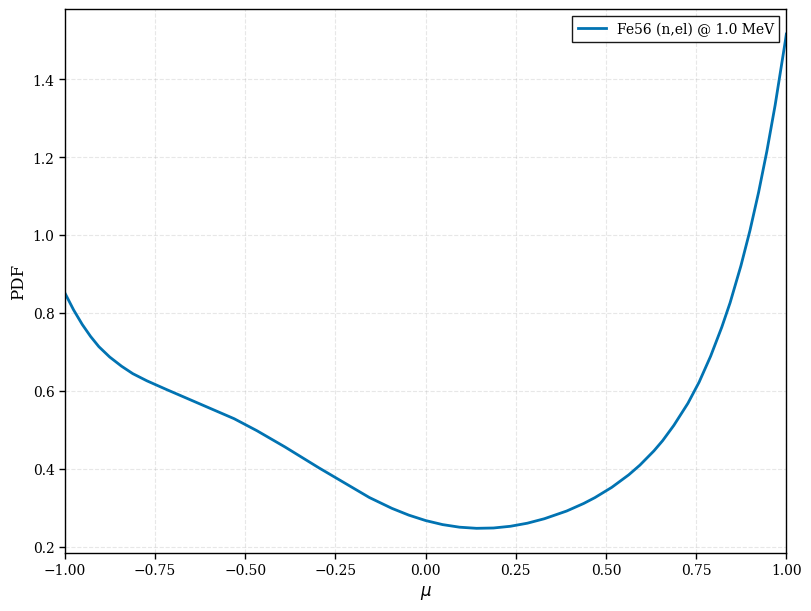

In [13]:
# Alternative: Use the Ace object's to_plot_data() method directly
# This is equivalent to ace.angular_distributions.to_plot_data()

data = ace.to_plot_data('ang', mt=2, energy=1.0)

fig = (PlotBuilder()
       .add_data(data)
       .set_labels(x_label=r'$\mu$', y_label='PDF')
       .build())
plt.show()

## 10. Dark Mode Style

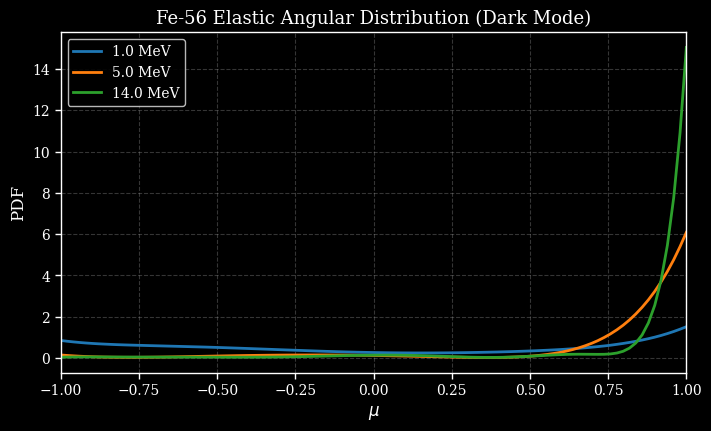

In [14]:
# Use dark style for presentations
energies = [1.0, 5.0, 14.0]
builder = PlotBuilder(style='dark', figsize=(10, 6))

for E in energies:
    data = ace.angular_distributions.to_plot_data(
        mt=2, energy=E, ace=ace, label=f'{E} MeV', interpolate=True
    )
    builder.add_data(data)

fig = (builder
       .set_labels(
           title='Fe-56 Elastic Angular Distribution (Dark Mode)',
           x_label=r'$\mu$',
           y_label='PDF'
       )
       .set_legend(loc='upper left')
       .build())
plt.show()